# Social media strategy — CRISP-DM walkthrough

Run cells **top to bottom**. We add **one phase at a time**; after each phase, review outputs before continuing.

**Six phases (what each answers):**

1. **Business understanding** — What decisions should social data support (content, timing, budget)?
2. **Data understanding** — Which tables describe posts, reach, engagement, and gifts tied to posts?
3. **Data preparation** — Build analysis-ready tables (joins, targets, features).
4. **Modeling** — Test hypotheses with stats/ML (e.g. what predicts referrals or engagement).
5. **Evaluation** — Are findings stable enough to act on given sample size?
6. **Deployment** — Dashboards, playbooks, or API hooks (often via your .NET stack).

**This notebook:** **Phases 1–6** are drafted below. Phase 6 **deploys the engagement-rate model** by stakeholder choice (helpful when the org is still building social capability); the FastAPI app loads it as **`POST /social/predict`** when `pipelines/social_engagement_pipeline_v1.sav` exists.



## Phase 1: Business understanding

### Decisions we want data to inform

1. **Content & format** — Which *post types*, *topics*, *tones*, and *media types* correlate with **engagement** and with **attributed gifts**?
2. **Channel mix** — How do **platforms** (Instagram, Facebook, LinkedIn, etc.) compare on reach vs. conversion signals?
3. **Timing** — Do **day of week**, **hour**, or **campaign** flags relate to outcomes?
4. **Paid vs organic** — Where **boost budget** or **is_boosted** might (or might not) pay off, given this dataset.

### Outcomes (“targets”) we might model later (not built yet)

- **Post-level:** `donation_referrals`, `estimated_donation_value_php`, `engagement_rate`, `click_throughs`, `likes`, etc. in `social_media_posts.csv`.
- **Gift-level link:** `donations.csv` includes `referral_post_id` → join to `post_id` to see which posts preceded concrete gifts.
- **Donor-level context:** `donor_and_potential_growth.csv` includes `social_referral_count` (rollup) for retention/growth stories—not a substitute for post-level analysis.

### Success criteria (business)

- Clear **ranking** of “what tends to work” on this historical sample, with **caveats** (correlation ≠ causation; small *N* on some platforms).
- Optional **rules of thumb** for editorial calendar and boost experiments—always validated with Phase 5.

### Scope boundaries

- We are **not** claiming incremental lift from experiments unless you have holdouts; we are **explaining variance** in observational data.
- **Peripheral** CSVs (residents, education, etc.) matter for mission storytelling; **Phase 2** tags which files are **directly** social-attributable vs. **context only**.

---

**Checkpoint — Phase 1:** If these questions match what your team wants from social analytics, run **Phase 2** to inventory the files under `Dataset/`.



## Phase 2: Data understanding

**What we do here:** Scan `Dataset/lighthouse_csv_v7/` for CSVs, mark which ones help **social media** analysis, then **profile** the primary table (`social_media_posts.csv`) and the **donation ↔ post** link via `referral_post_id`.

**After you run the next cell:** Skim printed row counts, column types, missingness, and join coverage.

**Checkpoint — Phase 2:** When satisfied, continue to **Phase 3: Data preparation** (next section).



In [6]:
# =============================================================================
# Phase 2 — Dataset inventory for social-media analytics
# =============================================================================
# This cell is intentionally heavy on comments so you can narrate it in a video
# or hand it to a teammate without re-reading CRISP-DM slides.
#
# Prerequisites: pandas; cwd can be repo root or a subfolder (we locate Dataset/ by walking up).

from pathlib import Path

import pandas as pd

# Jupyter provides display(); add a fallback so the cell never raises NameError
# (e.g. running as a plain .py script or some IDE "Run Cell" environments).
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

# -----------------------------------------------------------------------------
# 1) Lighthouse CSV bundle (paths relative to repo root)
# -----------------------------------------------------------------------------
_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError("Could not find Dataset/ — open Jupyter from inside the ml-pipelines repo.")
DATA_DIR = _repo / "Dataset" / "lighthouse_csv_v7"

# Primary table: one row per social post with reach/engagement/donation-proxy fields
SOCIAL_POSTS_PATH = DATA_DIR / "social_media_posts.csv"

# Transactional gifts — includes referral_post_id when the gift was tied to a post
DONATIONS_PATH = DATA_DIR / "donations.csv"

# Engineered supporter rollup (useful later for donor-level social activity counts)
ENGINEERED_DONOR_PATH = DATA_DIR / "Created .csv for Pipelines" / "donor_and_potential_growth.csv"

# Optional: monthly narrative metrics (aggregate; not post-level, but useful context)
PUBLIC_IMPACT_PATH = DATA_DIR / "public_impact_snapshots.csv"


# -----------------------------------------------------------------------------
# 2) Enumerate every CSV in the dataset folder (flat list)
# -----------------------------------------------------------------------------
# Why: Phase 1 asked "what exists?" — we answer mechanically so nothing is forgotten.
all_csv_files = sorted(DATA_DIR.glob("*.csv"))
print("=== All CSV files under lighthouse_csv_v7/ ===")
for p in all_csv_files:
    # len(pd.read_csv(..., usecols=[0])) is a cheap row count without loading full width
    try:
        n = len(pd.read_csv(p, usecols=[0]))
    except Exception as exc:
        n = f"(read error: {exc})"
    print(f"  {p.name}: {n} rows")

# -----------------------------------------------------------------------------
# 3) Tag files that are *especially* relevant to social-media questions
# -----------------------------------------------------------------------------
# "Primary" = post-level or direct attribution bridge.
# "Secondary" = enriches story or supporter context but is not a post log.
# "Peripheral" = other operations data (still valuable org-wide, not social-core).

PRIMARY_SOCIAL = {
    "social_media_posts.csv",  # main fact table for posts
    "donations.csv",           # links gifts -> referral_post_id -> post_id
}
SECONDARY_SOCIAL = {
    "donor_and_potential_growth.csv",  # supporter-level social_referral_count (in subfolder)
    "public_impact_snapshots.csv",    # monthly aggregates; good for trend context
}
# Files whose *names* hint at audience or comms (manual heuristic — refine in Phase 3)
NAME_HINTS = ("social", "media", "post", "campaign", "partner", "impact")

print("\n=== Social-relevance tags (heuristic) ===")
for p in all_csv_files:
    name = p.name.lower()
    tag = "peripheral"
    if p.name in PRIMARY_SOCIAL:
        tag = "PRIMARY (social / attribution)"
    elif p.name in SECONDARY_SOCIAL:
        tag = "SECONDARY (context)"
    elif any(h in name for h in NAME_HINTS):
        tag = "REVIEW (name hint — inspect in Phase 3)"
    print(f"  [{tag}] {p.name}")

# Subfolder engineered file (not in flat glob above)
if ENGINEERED_DONOR_PATH.is_file():
    n_eng = len(pd.read_csv(ENGINEERED_DONOR_PATH, usecols=[0]))
    print(f"\n  [SECONDARY rollup] {ENGINEERED_DONOR_PATH.relative_to(DATA_DIR)}: {n_eng} rows")

# -----------------------------------------------------------------------------
# 4) Load social_media_posts and inspect schema + missingness
# -----------------------------------------------------------------------------
# This is the workhorse table for "how we use social" questions at post grain.
posts = pd.read_csv(SOCIAL_POSTS_PATH)

print("\n=== social_media_posts.csv — shape & dtypes ===")
print(posts.shape)
print(posts.dtypes)

# Columns that usually matter for strategy (existence check — column names from your export)
candidate_metric_cols = [
    "impressions",
    "reach",
    "likes",
    "comments",
    "shares",
    "saves",
    "click_throughs",
    "video_views",
    "engagement_rate",
    "donation_referrals",
    "estimated_donation_value_php",
    "is_boosted",
    "boost_budget_php",
]
present_metrics = [c for c in candidate_metric_cols if c in posts.columns]
missing_metrics = [c for c in candidate_metric_cols if c not in posts.columns]
print("\nMetric-like columns found:", present_metrics)
if missing_metrics:
    print("(Expected but missing — rename or engineer in Phase 3):", missing_metrics)

print("\nMissing values (top columns with any NA):")
na_counts = posts.isnull().sum().sort_values(ascending=False)
print(na_counts[na_counts > 0].head(20))

# Quick categorical distributions — helps you talk about "what we post"
print("\n=== Post mix: platform (where we publish) ===")
print(posts["platform"].value_counts(dropna=False).head(15))

print("\n=== Post mix: content_topic (what we talk about) ===")
if "content_topic" in posts.columns:
    print(posts["content_topic"].value_counts(dropna=False).head(15))

print("\n=== Post mix: post_type (format intent) ===")
if "post_type" in posts.columns:
    print(posts["post_type"].value_counts(dropna=False).head(15))

# -----------------------------------------------------------------------------
# 5) Link donations to posts (attribution bridge)
# -----------------------------------------------------------------------------
# If referral_post_id is populated, we can count gifts that cite a specific post.
donations = pd.read_csv(DONATIONS_PATH)

if "referral_post_id" not in donations.columns:
    print("\n[WARN] donations.csv has no referral_post_id — cannot join to posts by id.")
else:
    ref = donations["referral_post_id"]
    n_with_ref = int(ref.notna().sum())
    print(f"\n=== Donation → post link ===")
    print(f"Donations rows: {len(donations)}")
    print(f"Rows with non-null referral_post_id: {n_with_ref}")

    # Validate that referred ids exist in the posts table (data quality check)
    post_ids = set(posts["post_id"].dropna().astype(int).values)
    ref_int = donations.loc[ref.notna(), "referral_post_id"].astype(int)
    matched = ref_int.isin(post_ids).sum()
    print(f"referral_post_id values matching social_media_posts.post_id: {matched} / {n_with_ref}")

    # Example: attributed estimated gift value by referred post (Monetary rows use estimated_value)
    if "estimated_value" in donations.columns and "donation_type" in donations.columns:
        d2 = donations[ref.notna()].copy()
        d2["referral_post_id"] = d2["referral_post_id"].astype(int)
        by_post = (
            d2.groupby("referral_post_id", as_index=False)
            .agg(
                n_gifts=("donation_id", "count"),
                sum_estimated_value=("estimated_value", lambda s: pd.to_numeric(s, errors="coerce").sum()),
            )
        )
        print("\nTop 5 posts by count of referred gifts:")
        display(by_post.sort_values("n_gifts", ascending=False).head())

# -----------------------------------------------------------------------------
# 6) Optional: supporter-level social signal (rollup file)
# -----------------------------------------------------------------------------
# social_referral_count = how often this donor's giving touched social-attributed flows
# (definition matches your engineered features doc — good for donor CRM, not post creative.)
if ENGINEERED_DONOR_PATH.is_file():
    # read_csv has no "errors=" kwarg; load then select columns if present
    donors = pd.read_csv(ENGINEERED_DONOR_PATH)
    if "social_referral_count" in donors.columns:
        print("\n=== Engineered donor rollup: social_referral_count describe ===")
        display(donors["social_referral_count"].describe())

# -----------------------------------------------------------------------------
# 7) End of Phase 2 — what Phase 3 will need to decide
# -----------------------------------------------------------------------------
# - Target variable(s): e.g. donation_referrals vs engagement_rate (different questions).
# - Unit of analysis: post-level vs campaign-level vs weekly aggregates.
# - Leakage: do not use post-hoc totals as "inputs" for the same row without time discipline.
print("\n=== Phase 2 complete ===")
print("Next (Phase 3): define clean X/y or hypothesis tables; document joins and filters.")


=== All CSV files under lighthouse_csv_v7/ ===
  donation_allocations.csv: 521 rows
  donations.csv: 420 rows
  education_records.csv: 534 rows
  health_wellbeing_records.csv: 534 rows
  home_visitations.csv: 1337 rows
  in_kind_donation_items.csv: 129 rows
  incident_reports.csv: 100 rows
  intervention_plans.csv: 180 rows
  partner_assignments.csv: 48 rows
  partners.csv: 30 rows
  process_recordings.csv: 2819 rows
  public_impact_snapshots.csv: 50 rows
  residents.csv: 60 rows
  safehouse_monthly_metrics.csv: 450 rows
  safehouses.csv: 9 rows
  social_media_posts.csv: 812 rows
  supporters.csv: 60 rows

=== Social-relevance tags (heuristic) ===
  [peripheral] donation_allocations.csv
  [PRIMARY (social / attribution)] donations.csv
  [peripheral] education_records.csv
  [peripheral] health_wellbeing_records.csv
  [peripheral] home_visitations.csv
  [peripheral] in_kind_donation_items.csv
  [peripheral] incident_reports.csv
  [peripheral] intervention_plans.csv
  [REVIEW (name hint —

,referral_post_id,n_gifts,sum_estimated_value
17,211,3,746.16
28,421,3,2769.69
15,200,3,1652.48
11,159,3,837.22
19,221,3,2582.10



=== Engineered donor rollup: social_referral_count describe ===


count    60.000000
mean      1.283333
std       1.222552
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       5.000000
Name: social_referral_count, dtype: float64


=== Phase 2 complete ===
Next (Phase 3): define clean X/y or hypothesis tables; document joins and filters.


## Phase 3: Data preparation

**What we do here:** Turn raw `social_media_posts` + `donations` into **one analysis-ready row per post** with consistent types, sensible missing-value rules, and **gift totals joined from real donation rows** (`referral_post_id`). We then name **candidate feature columns (X)** and **candidate targets (y)** for Phase 4.

**Design choices (documented in code):**

- **Post-native outcomes** — columns already on each post (e.g. `engagement_rate`, `donation_referrals`) are easy targets but remember they are **observational**; gifts joined from `donations.csv` are a **cross-check** (`n_referred_donations`, `sum_referred_estimated_value`).
- **Leakage rule for Phase 4** — when predicting **referrals or gifts**, do **not** use other post-level “outcome-ish” fields as inputs (e.g. `estimated_donation_value_php` on the same row) unless you confirm in the data dictionary they are not derived from the target. The code stores separate lists: `FEATURES_ENGAGEMENT_MODEL` vs `FEATURES_REFERRAL_MODEL`.

**Checkpoint — Phase 3:** Run the next cell, inspect `posts_modeling.shape` and sample rows, then continue to **Phase 4: Modeling**.

In [7]:
# =============================================================================
# Phase 3 — Data preparation (social posts + gift rollups, feature/target lists)
# =============================================================================
# Verbose comments: every block states intent so graders / teammates can follow.
# Run after Phase 2 (or standalone: paths below are self-contained).

from pathlib import Path
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 0) Paths (same layout as retention / growth notebooks)
# -----------------------------------------------------------------------------
_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError("Could not find Dataset/ — open Jupyter from inside the ml-pipelines repo.")
DATASET = _repo / "Dataset" / "lighthouse_csv_v7"
POSTS_CSV = DATASET / "social_media_posts.csv"
DONATIONS_CSV = DATASET / "donations.csv"

# -----------------------------------------------------------------------------
# 1) display() in plain Python vs Jupyter
# -----------------------------------------------------------------------------
try:
    from IPython.display import display as ipy_display
except ImportError:
    def ipy_display(obj, **kwargs):
        if hasattr(obj, "head"):
            print(obj.head().to_string())
        else:
            print(obj)

# -----------------------------------------------------------------------------
# 2) Load sources
# -----------------------------------------------------------------------------
posts_raw = pd.read_csv(POSTS_CSV, low_memory=False)
donations = pd.read_csv(DONATIONS_CSV, low_memory=False)

# -----------------------------------------------------------------------------
# 3) Post-level cleaning — types and time
# -----------------------------------------------------------------------------
posts = posts_raw.copy()

# Parse post timestamp (ISO-like strings in sample); invalid → NaT for audit
posts["created_at"] = pd.to_datetime(posts["created_at"], errors="coerce")

# Calendar features (useful for “daypart” / seasonality without leaking future info
# when you later split by time — still document train cutoff in Phase 4)
posts["post_hour"] = posts["created_at"].dt.hour
posts["post_dow"] = posts["created_at"].dt.day_name()
posts["post_dow"] = posts["post_dow"].astype("string").fillna("Unknown")

# -----------------------------------------------------------------------------
# 4) Categorical columns — stable "Unknown" bucket (keeps one-hot cardinality bounded)
# -----------------------------------------------------------------------------
CAT_FILL = [
    "platform",
    "post_type",
    "media_type",
    "content_topic",
    "sentiment_tone",
    "day_of_week",
    "call_to_action_type",
    "campaign_name",
]
for col in CAT_FILL:
    if col in posts.columns:
        posts[col] = posts[col].astype("string").fillna("Unknown").replace("", "Unknown")

# -----------------------------------------------------------------------------
# 5) Numeric columns — fill strategy documented per field
# -----------------------------------------------------------------------------
# Engagement / reach metrics: NaN often means “not tracked for this post type” → 0
COUNT_LIKE_COLS = [
    "impressions",
    "reach",
    "likes",
    "comments",
    "shares",
    "saves",
    "click_throughs",
    "caption_length",
    "num_hashtags",
    "mentions_count",
    "follower_count_at_post",
]
for c in COUNT_LIKE_COLS:
    if c in posts.columns:
        posts[c] = pd.to_numeric(posts[c], errors="coerce").fillna(0)

# Video-specific: only video/reel posts should have views; others → 0
if "video_views" in posts.columns:
    posts["video_views"] = pd.to_numeric(posts["video_views"], errors="coerce").fillna(0)

# Boost budget: NaN → 0 means “no paid boost recorded”
if "boost_budget_php" in posts.columns:
    posts["boost_budget_php"] = pd.to_numeric(posts["boost_budget_php"], errors="coerce").fillna(0)

# Boolean post flags → 0/1 for tree / linear models with numeric pipelines
for bcol in ("has_call_to_action", "is_boosted"):
    if bcol in posts.columns:
        posts[bcol] = posts[bcol].astype("boolean").fillna(False).astype(np.int8)

# Post-native targets / rates — keep NaN visible for audit, then fill only for modeling rows
if "engagement_rate" in posts.columns:
    posts["engagement_rate"] = pd.to_numeric(posts["engagement_rate"], errors="coerce")
if "donation_referrals" in posts.columns:
    posts["donation_referrals"] = pd.to_numeric(posts["donation_referrals"], errors="coerce").fillna(0)
if "estimated_donation_value_php" in posts.columns:
    posts["estimated_donation_value_php"] = pd.to_numeric(
        posts["estimated_donation_value_php"], errors="coerce"
    )

# -----------------------------------------------------------------------------
# 6) Gift rollups from donations (ground-truth rows with referral_post_id)
# -----------------------------------------------------------------------------
# Normalize ids to integers: pandas often reads referral_post_id as float, and
# astype("string") yields "421.0" while post_id stringifies as "421" — merge would miss.
ref = donations.copy()
ref["referral_post_id_int"] = pd.to_numeric(ref["referral_post_id"], errors="coerce")
ref = ref[ref["referral_post_id_int"].notna()]
ref["donation_date"] = pd.to_datetime(ref["donation_date"], errors="coerce")

gift_rollup = (
    ref.groupby("referral_post_id_int", dropna=False)
    .agg(
        n_referred_donations=("donation_id", "count"),
        # donations.csv uses estimated_value (PHP-equivalent amount in this extract)
        sum_referred_estimated_value=("estimated_value", "sum"),
        first_referred_gift_at=("donation_date", "min"),
    )
    .reset_index()
)

# -----------------------------------------------------------------------------
# 7) Merge rollups onto posts (left join — posts with no referred gifts get zeros)
# -----------------------------------------------------------------------------
posts["post_id_int"] = pd.to_numeric(posts["post_id"], errors="coerce").astype("Int64")
posts_enriched = posts.merge(
    gift_rollup,
    left_on="post_id_int",
    right_on="referral_post_id_int",
    how="left",
)
posts_enriched = posts_enriched.drop(columns=["referral_post_id_int", "post_id_int"])
posts_enriched["n_referred_donations"] = posts_enriched["n_referred_donations"].fillna(0).astype(int)
posts_enriched["sum_referred_estimated_value"] = posts_enriched["sum_referred_estimated_value"].fillna(0.0)

# Binary outcome from actual gifts (useful if post-level donation_referrals is noisy)
posts_enriched["has_referred_gift"] = (posts_enriched["n_referred_donations"] > 0).astype(int)

# -----------------------------------------------------------------------------
# 8) Modeling frame — drop rows with broken timestamps if you need time-based CV later
# -----------------------------------------------------------------------------
posts_modeling = posts_enriched.copy()
# Optional strict filter (uncomment for time-split modeling):
# posts_modeling = posts_modeling[posts_modeling["created_at"].notna()].copy()

# -----------------------------------------------------------------------------
# 9) Feature / target lists for Phase 4 (separate lists reduce leakage mistakes)
# -----------------------------------------------------------------------------
# Pre-posting inputs: what is known BEFORE or AT TIME OF posting.
# Safe for ALL models; these cannot be leaking engagement or referral outcomes.
FEATURES_PRE_POST_NUMERIC = [
    c
    for c in [
        "caption_length",
        "num_hashtags",
        "mentions_count",
        "boost_budget_php",
        "follower_count_at_post",
        "post_hour",
        "has_call_to_action",
        "is_boosted",
    ]
    if c in posts_modeling.columns
]

# Post-posting engagement outcome metrics (measured AFTER the post goes live).
# engagement_rate is computed from these components, so they must NOT appear in
# the engagement model’s feature set — that would be definitional/circular leakage.
# They ARE valid features for referral/gift models (separate outcome axis).
FEATURES_POST_ENGAGEMENT_NUMERIC = [
    c
    for c in [
        "impressions",
        "reach",
        "likes",
        "comments",
        "shares",
        "saves",
        "click_throughs",
        "video_views",
    ]
    if c in posts_modeling.columns
]

FEATURES_BASE_CATEGORICAL = [
    c
    for c in [
        "platform",
        "post_type",
        "media_type",
        "content_topic",
        "sentiment_tone",
        # Use post_dow from created_at (matches post_hour); CSV day_of_week kept on table for audit only
        "post_dow",
        "call_to_action_type",
        "campaign_name",
    ]
    if c in posts_modeling.columns
]

# Model A — predict engagement_rate: use pre-post features ONLY.
# likes/comments/shares/saves/click_throughs are components of the engagement_rate
# formula; using them to predict engagement_rate is circular (definitional leakage).
FEATURES_ENGAGEMENT_MODEL = FEATURES_PRE_POST_NUMERIC + FEATURES_BASE_CATEGORICAL
TARGET_ENGAGEMENT = "engagement_rate"

# Model B/C — predict referral activity: engagement metrics are valid predictors
# (separate outcome axis from donation referrals).
FEATURES_REFERRAL_MODEL = FEATURES_PRE_POST_NUMERIC + FEATURES_POST_ENGAGEMENT_NUMERIC + FEATURES_BASE_CATEGORICAL
TARGET_REFERRAL_COUNT = "donation_referrals"
TARGET_REFERRAL_BINARY = "has_referred_gift"

# -----------------------------------------------------------------------------
# 10) Quick QA summary (print + head)
# -----------------------------------------------------------------------------
print("posts_modeling shape:", posts_modeling.shape)
print(
    "Gift linkage: posts with ≥1 referred gift (from donations):",
    int((posts_modeling["has_referred_gift"] == 1).sum()),
)
print("Missing created_at:", int(posts_modeling["created_at"].isna().sum()))
if "engagement_rate" in posts_modeling.columns:
    print("Missing engagement_rate:", int(posts_modeling["engagement_rate"].isna().sum()))
ipy_display(posts_modeling.head(3))

posts_modeling shape: (812, 44)
Gift linkage: posts with ≥1 referred gift (from donations): 62
Missing created_at: 0
Missing engagement_rate: 0


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards,post_dow,n_referred_donations,sum_referred_estimated_value,first_referred_gift_at,has_referred_gift
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,1522,NaN,NaN,NaN,50.0,Thursday,0,0.0,NaT,0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,1833,NaN,NaN,NaN,NaN,Friday,0,0.0,NaT,0
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,457,NaN,NaN,NaN,NaN,Sunday,0,0.0,NaT,0


## Phase 4: Modeling

**What we do here:** Put the same **numeric + categorical preprocessing** (median impute + scale; mode impute + one-hot) inside a **`Pipeline`** with each candidate model, then compare models with **cross-validation**—the preprocessor refits **inside each training fold** so target leakage does not creep in.

We train **three related tasks** (all use the Phase 3 feature set, not gift-rollup columns as inputs):

| Task | Target | CV | Selection rule |
|------|--------|----|----------------|
| **Engagement** | `engagement_rate` | 5-fold **KFold** (shuffled) | Lowest mean **MAE**, tie-break higher **R²** |
| **Referral count** | `donation_referrals` (post-level) | Same | Lowest mean **MAE**, tie-break higher **R²** |
| **Referred gift (binary)** | `has_referred_gift` (from `donations`) | **Stratified** 5-fold | Highest mean **F1 macro**, tie-break **ROC-AUC** |

**Talking points:** *N* ≈ 800 posts is healthier than the 60-row donor notebooks, but **class imbalance** on `has_referred_gift` (~8% positive) means F1 macro matters more than raw accuracy. Count targets are **skewed** (long tail of `donation_referrals`); MAE is a blunt summary—Phase 5 can add residual plots.

**Checkpoint — Phase 4:** Review the three leaderboards, then run **Phase 5: Evaluation** (OOF diagnostics + primary-model choice for Phase 6).

In [8]:
# =============================================================================
# Phase 4 — Modeling: CV model selection for engagement, referral count, gift binary
# =============================================================================
# Prerequisite: run Phase 3 so `posts_modeling` and FEATURES_* / TARGET_* exist.
# Pattern matches donor_growth (regression MAE) and donor_retention (classification F1).

import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from IPython.display import display as ipy_display
except ImportError:
    def ipy_display(obj, **kwargs):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)


def build_social_preprocessor(
    numeric_features: list,
    categorical_features: list,
) -> ColumnTransformer:
    """Numeric: median impute + scale. Categorical: mode impute + one-hot (ignore unknown)."""
    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ]
    )


# Per-model feature lists from Phase 3:
#  FEATURES_ENGAGEMENT_MODEL        — pre-post inputs only (no engagement components)
#  FEATURES_REFERRAL_MODEL          — pre-post + post-engagement metrics
#  FEATURES_BASE_CATEGORICAL        — shared categorical inputs


def make_engagement_prep():
    """Preprocessor for the engagement_rate model (pre-post numeric + categorical)."""
    _num = [c for c in FEATURES_ENGAGEMENT_MODEL if c not in FEATURES_BASE_CATEGORICAL]
    return build_social_preprocessor(_num, FEATURES_BASE_CATEGORICAL)


def make_referral_prep():
    """Preprocessor for referral/gift models (pre-post + post-engagement numeric + categorical)."""
    _num = [c for c in FEATURES_REFERRAL_MODEL if c not in FEATURES_BASE_CATEGORICAL]
    return build_social_preprocessor(_num, FEATURES_BASE_CATEGORICAL)


def make_prep():
    """Legacy alias used in Phase 5 OOF clones — points to the deployed engagement prep."""
    return make_engagement_prep()


# -----------------------------------------------------------------------------
# 4a) Regression — engagement_rate
# -----------------------------------------------------------------------------
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate

df_eng = posts_modeling.dropna(subset=[TARGET_ENGAGEMENT]).copy()
X_eng = df_eng[FEATURES_ENGAGEMENT_MODEL]
y_eng = df_eng[TARGET_ENGAGEMENT]

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
scoring_reg = {"neg_mae": "neg_mean_absolute_error", "r2": "r2"}

candidate_regressors = {
    "gradient_boosting": GradientBoostingRegressor(
        random_state=42,
        max_depth=3,
        n_estimators=120,
        learning_rate=0.08,
        subsample=0.9,
    ),
    "hist_gradient_boosting": HistGradientBoostingRegressor(
        random_state=42,
        max_depth=4,
        max_iter=200,
        learning_rate=0.06,
        min_samples_leaf=3,
    ),
    "random_forest": RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=3,
    ),
    "ridge": Ridge(alpha=1.0),
}

rows_eng = []
cv_eng_by_name = {}
for name, reg in candidate_regressors.items():
    pipe = Pipeline(
        steps=[("prep", make_engagement_prep()), ("reg", clone(reg))],
    )
    scores = cross_validate(
        pipe,
        X_eng,
        y_eng,
        cv=cv_reg,
        scoring=scoring_reg,
        return_train_score=True,
    )
    cv_eng_by_name[name] = scores
    rows_eng.append(
        {
            "model": name,
            "cv_mae_mean": -scores["test_neg_mae"].mean(),
            "cv_mae_std": scores["test_neg_mae"].std(),
            "cv_r2_mean": scores["test_r2"].mean(),
            "cv_r2_std": scores["test_r2"].std(),
        }
    )

leaderboard_engagement = pd.DataFrame(rows_eng).sort_values(
    ["cv_mae_mean", "cv_r2_mean"], ascending=[True, False]
)
print("=== Engagement (regression): lower MAE is better; tie-break higher R² ===")
ipy_display(leaderboard_engagement)

best_eng = leaderboard_engagement.iloc[0]["model"]
social_engagement_model_name = best_eng
social_engagement_cv_scores = cv_eng_by_name[best_eng]
social_engagement_pipeline = Pipeline(
    steps=[
        ("prep", make_engagement_prep()),
        ("reg", clone(candidate_regressors[best_eng])),
    ]
)
social_engagement_pipeline.fit(X_eng, y_eng)
print(
    f"\nSelected engagement model: {best_eng} | rows={len(X_eng)} | "
    f"CV MAE { -social_engagement_cv_scores['test_neg_mae'].mean():.4f} ± "
    f"{social_engagement_cv_scores['test_neg_mae'].std():.4f}\n"
)

# -----------------------------------------------------------------------------
# 4b) Regression — donation_referrals (post-reported count; heavy tail)
# -----------------------------------------------------------------------------
X_ref = posts_modeling[FEATURES_REFERRAL_MODEL]
y_ref = posts_modeling[TARGET_REFERRAL_COUNT]

rows_ref = []
cv_ref_by_name = {}
for name, reg in candidate_regressors.items():
    pipe = Pipeline(
        steps=[("prep", make_referral_prep()), ("reg", clone(reg))],
    )
    scores = cross_validate(
        pipe,
        X_ref,
        y_ref,
        cv=cv_reg,
        scoring=scoring_reg,
        return_train_score=True,
    )
    cv_ref_by_name[name] = scores
    rows_ref.append(
        {
            "model": name,
            "cv_mae_mean": -scores["test_neg_mae"].mean(),
            "cv_mae_std": scores["test_neg_mae"].std(),
            "cv_r2_mean": scores["test_r2"].mean(),
            "cv_r2_std": scores["test_r2"].std(),
        }
    )

leaderboard_referral_count = pd.DataFrame(rows_ref).sort_values(
    ["cv_mae_mean", "cv_r2_mean"], ascending=[True, False]
)
print("=== Referral count (regression): same metric policy ===")
ipy_display(leaderboard_referral_count)

best_ref = leaderboard_referral_count.iloc[0]["model"]
social_referral_count_model_name = best_ref
social_referral_count_cv_scores = cv_ref_by_name[best_ref]
social_referral_count_pipeline = Pipeline(
    steps=[
        ("prep", make_referral_prep()),
        ("reg", clone(candidate_regressors[best_ref])),
    ]
)
social_referral_count_pipeline.fit(X_ref, y_ref)
print(
    f"\nSelected referral-count model: {best_ref} | rows={len(X_ref)} | "
    f"CV MAE { -social_referral_count_cv_scores['test_neg_mae'].mean():.2f} ± "
    f"{social_referral_count_cv_scores['test_neg_mae'].std():.2f}\n"
)

# -----------------------------------------------------------------------------
# 4c) Classification — has_referred_gift (stratified CV; minority class ~8%)
# -----------------------------------------------------------------------------
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

X_gift = posts_modeling[FEATURES_REFERRAL_MODEL]
y_gift = posts_modeling[TARGET_REFERRAL_BINARY]

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_clf = {"acc": "accuracy", "f1_macro": "f1_macro", "roc_auc": "roc_auc"}

candidate_classifiers = {
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
    ),
    "logistic_regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42,
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        max_depth=4,
        max_iter=200,
        learning_rate=0.08,
        class_weight="balanced",
        random_state=42,
    ),
    "svc_rbf": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42,
    ),
}

rows_gift = []
cv_gift_by_name = {}
for name, clf in candidate_classifiers.items():
    pipe = Pipeline(
        steps=[("prep", make_referral_prep()), ("clf", clone(clf))],
    )
    scores = cross_validate(
        pipe,
        X_gift,
        y_gift,
        cv=cv_clf,
        scoring=scoring_clf,
        return_train_score=True,
    )
    cv_gift_by_name[name] = scores
    rows_gift.append(
        {
            "model": name,
            "cv_acc_mean": scores["test_acc"].mean(),
            "cv_acc_std": scores["test_acc"].std(),
            "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
            "cv_f1_macro_std": scores["test_f1_macro"].std(),
            "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
            "cv_roc_auc_std": scores["test_roc_auc"].std(),
        }
    )

leaderboard_gift = pd.DataFrame(rows_gift).sort_values(
    ["cv_f1_macro_mean", "cv_roc_auc_mean"], ascending=False
)
print("=== Referred gift (binary): higher F1 macro; tie-break ROC-AUC ===")
ipy_display(leaderboard_gift)

best_gift = leaderboard_gift.iloc[0]["model"]
social_gift_model_name = best_gift
social_gift_cv_scores = cv_gift_by_name[best_gift]
social_gift_pipeline = Pipeline(
    steps=[
        ("prep", make_referral_prep()),
        ("clf", clone(candidate_classifiers[best_gift])),
    ]
)
social_gift_pipeline.fit(X_gift, y_gift)
print(
    f"\nSelected gift classifier: {best_gift} | rows={len(X_gift)} | "
    f"positive rate={y_gift.mean():.3f} | "
    f"CV F1 macro {social_gift_cv_scores['test_f1_macro'].mean():.3f} ± "
    f"{social_gift_cv_scores['test_f1_macro'].std():.3f}\n"
)

# For Phase 5 OOF evaluation: same CV objects and estimator templates (cross_val_predict clones unfitted pipes)
SOCIAL_CV_REG = cv_reg
SOCIAL_CV_CLF = cv_clf
SOCIAL_REG_CANDIDATES = candidate_regressors
SOCIAL_CLF_CANDIDATES = candidate_classifiers

print(
    "Fitted pipelines: `social_engagement_pipeline`, `social_referral_count_pipeline`, "
    "`social_gift_pipeline` (full data fits for Phase 6 export / API)."
)

=== Engagement (regression): lower MAE is better; tie-break higher R² ===


/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self

,model,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
1,hist_gradient_boosting,0.018605,0.001743,0.791229,0.026580
0,gradient_boosting,0.019889,0.001656,0.768399,0.019557
2,random_forest,0.026358,0.002014,0.620530,0.019742
3,ridge,0.035885,0.001747,0.359688,0.025571



Selected engagement model: hist_gradient_boosting | rows=812 | CV MAE 0.0186 ± 0.0017

=== Referral count (regression): same metric policy ===


/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self

...


Selected referral-count model: random_forest | rows=812 | CV MAE 5.84 ± 1.08



/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

=== Referred gift (binary): higher F1 macro; tie-break ROC-AUC ===


,model,cv_acc_mean,cv_acc_std,cv_f1_macro_mean,cv_f1_macro_std,cv_roc_auc_mean,cv_roc_auc_std
2,hist_gradient_boosting,0.890404,0.005851,0.552343,0.026295,0.615744,0.026747
3,svc_rbf,0.833742,0.018313,0.523810,0.024592,0.626803,0.050429
0,random_forest,0.915027,0.005995,0.502848,0.030575,0.647752,0.076359
1,logistic_regression,0.705612,0.029519,0.490655,0.029879,0.593607,0.034293



Selected gift classifier: hist_gradient_boosting | rows=812 | positive rate=0.076 | CV F1 macro 0.552 ± 0.026

Fitted pipelines: `social_engagement_pipeline`, `social_referral_count_pipeline`, `social_gift_pipeline` (full data fits for Phase 6 export / API).


## Phase 5: Evaluation

**What we do here:** Score each **Phase 4 winner** honestly using **out-of-fold (OOF)** predictions—the same cross-validation splits as modeling, so every row is predicted only when it sat in the validation fold. We add **actual vs predicted** and **residual** plots for the two regressions, a **confusion matrix** and **ROC curve** for the gift classifier, and compare each model to a **naive baseline** (mean predictor / majority class).

**Three different targets** mean three different metrics; we still pick **one primary fitted pipeline** for Phase 6 using a transparent rule: map each task to a **0–1 strength score** (R² for regressions; \((\mathrm{ROC\text{-}AUC} - 0.5) \times 2\) for classification so 0.5 AUC → 0 and 1.0 → 1), then take the **argmax**. That favors whichever model extracts the most signal on this sample—not a universal “truth,” but a consistent way to **move forward with one artifact**.

**Talking points:** Strong **train vs CV gap** (from Phase 4) plus OOF plots that fan out at high fitted values usually mean **don’t over-trust point predictions**—use rankings and segments instead. The gift model is **imbalanced**; accuracy can look high while ROC-AUC and F1 macro tell a fairer story.

**Checkpoint — Phase 5:** Review OOF diagnostics and the automated rank score; **Phase 6** locks deployment to the **engagement** model by explicit nonprofit/stakeholder choice (even if another task scored higher).

=== Engagement (`engagement_rate`) — out-of-fold ===
MAE:  0.0186   | dummy (mean): 0.0458
RMSE: 0.0252
R²:   0.794
(Phase 4 already printed train vs CV; large gaps hint at overfitting.)



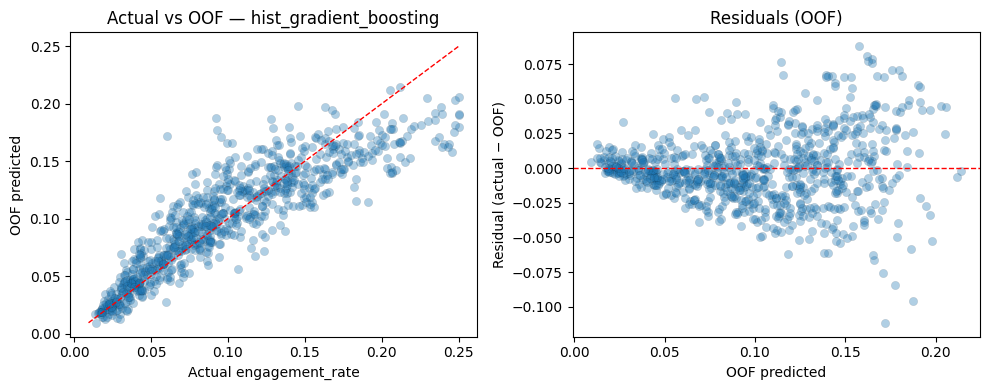

Largest |OOF error| — engagement (top 8)


,post_id,actual,pred_oof,abs_err
151,91,0.0605,0.172069,0.111569
453,559,0.0920,0.187683,0.095683
450,684,0.2457,0.157799,0.087901
294,206,0.0927,0.177378,0.084678
255,584,0.2432,0.162201,0.080999
145,758,0.2434,0.164868,0.078532
525,269,0.2394,0.162490,0.076910
364,377,0.1909,0.114587,0.076313



=== Referral count (`donation_referrals`) — out-of-fold ===
MAE:  5.84   | dummy (mean): 16.45
RMSE: 17.59
R²:   0.683



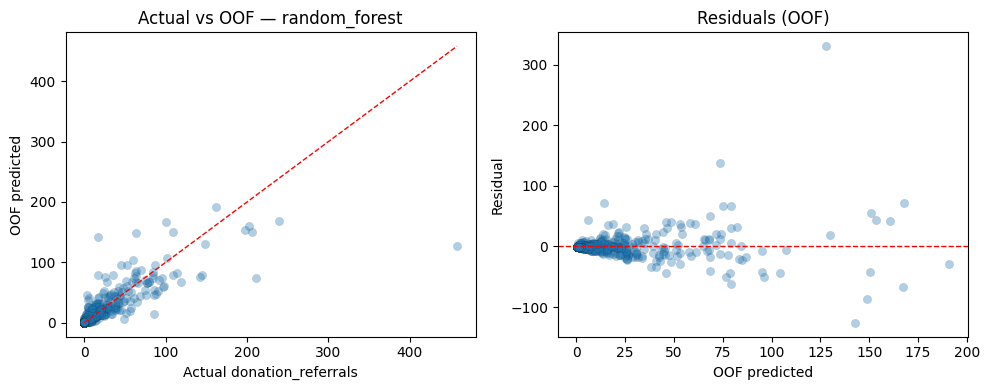

Largest |OOF error| — referral count (top 8)


,post_id,actual,pred_oof,abs_err
495,266,458,127.760392,330.239608
714,58,211,73.561738,137.438262
255,584,17,142.767181,125.767181
43,159,63,148.842048,85.842048
744,497,86,13.906390,72.093610
524,765,239,167.977298,71.022702
206,503,142,75.309661,66.690339
627,180,101,167.570240,66.570240



=== Referred gift (`has_referred_gift`) — out-of-fold ===
ROC-AUC:   0.614
F1 macro:  0.555   | dummy (most_frequent): 0.480
Accuracy:  0.890
Confusion matrix (rows=true, cols=pred):
[[714  36]
 [ 53   9]]

               precision    recall  f1-score   support

           0      0.931     0.952     0.941       750
           1      0.200     0.145     0.168        62

    accuracy                          0.890       812
   macro avg      0.565     0.549     0.555       812
weighted avg      0.875     0.890     0.882       812



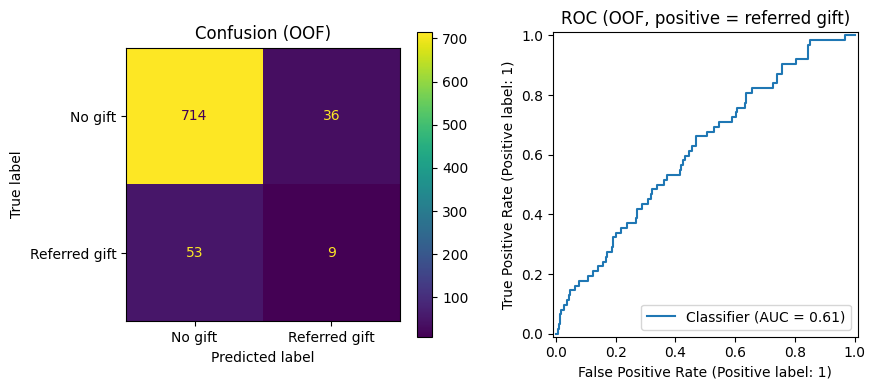


=== Which model to carry to Phase 6? (higher rank_score_0_1 wins) ===


,target,phase4_model,oof_key_metric,rank_score_0_1
0,engagement_rate,hist_gradient_boosting,0.793608,0.793608
1,donation_referrals,random_forest,0.683181,0.683181
2,has_referred_gift,hist_gradient_boosting,0.614323,0.228645



*** PRIMARY FOR PHASE 6: task=engagement | target column=`engagement_rate` | rank_score=0.794 ***
Use `social_pipeline_phase6.predict(X_new)` for point predictions.

(No fixed importances for HistGradientBoostingRegressor — try SHAP in a follow-on.)


In [9]:
# =============================================================================
# Phase 5 — OOF evaluation + choose one primary pipeline for Phase 6
# =============================================================================
# Requires Phase 4 (pipelines fitted, SOCIAL_* exports, X_eng / y_eng / X_ref / y_ref / X_gift / y_gift, df_eng).

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline

try:
    from IPython.display import display as ipy_display
except ImportError:
    def ipy_display(obj, **kwargs):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)


def _rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


# --- Unfitted clones of the Phase 4 winners (cross_val_predict refits each fold) ---
pipe_eng_oof = Pipeline(
    [
        ("prep", make_engagement_prep()),
        ("reg", clone(SOCIAL_REG_CANDIDATES[social_engagement_model_name])),
    ]
)
y_oof_eng = cross_val_predict(pipe_eng_oof, X_eng, y_eng, cv=SOCIAL_CV_REG)

pipe_ref_oof = Pipeline(
    [
        ("prep", make_referral_prep()),
        ("reg", clone(SOCIAL_REG_CANDIDATES[social_referral_count_model_name])),
    ]
)
y_oof_ref = cross_val_predict(pipe_ref_oof, X_ref, y_ref, cv=SOCIAL_CV_REG)

pipe_gift_oof = Pipeline(
    [
        ("prep", make_referral_prep()),
        ("clf", clone(SOCIAL_CLF_CANDIDATES[social_gift_model_name])),
    ]
)
y_oof_gift = cross_val_predict(pipe_gift_oof, X_gift, y_gift, cv=SOCIAL_CV_CLF)
y_proba_gift_oof = cross_val_predict(
    pipe_gift_oof, X_gift, y_gift, cv=SOCIAL_CV_CLF, method="predict_proba"
)[:, 1]

# --- Naive baselines (same CV, honest comparison) ---
y_dummy_eng = cross_val_predict(
    DummyRegressor(strategy="mean"), X_eng, y_eng, cv=SOCIAL_CV_REG
)
y_dummy_ref = cross_val_predict(
    DummyRegressor(strategy="mean"), X_ref, y_ref, cv=SOCIAL_CV_REG
)
y_dummy_gift = cross_val_predict(
    DummyClassifier(strategy="most_frequent"), X_gift, y_gift, cv=SOCIAL_CV_CLF
)

# -----------------------------------------------------------------------------
# 5a) Engagement regression
# -----------------------------------------------------------------------------
mae_eng = mean_absolute_error(y_eng, y_oof_eng)
mae_eng_dum = mean_absolute_error(y_eng, y_dummy_eng)
r2_eng = r2_score(y_eng, y_oof_eng)

print("=== Engagement (`engagement_rate`) — out-of-fold ===")
print(f"MAE:  {mae_eng:.4f}   | dummy (mean): {mae_eng_dum:.4f}")
print(f"RMSE: {_rmse(y_eng, y_oof_eng):.4f}")
print(f"R²:   {r2_eng:.3f}")
print("(Phase 4 already printed train vs CV; large gaps hint at overfitting.)\n")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax0, ax1 = axes
ax0.scatter(y_eng, y_oof_eng, alpha=0.35, edgecolors="k", linewidths=0.15)
lo = min(float(y_eng.min()), float(np.min(y_oof_eng)))
hi = max(float(y_eng.max()), float(np.max(y_oof_eng)))
ax0.plot([lo, hi], [lo, hi], "r--", lw=1)
ax0.set_xlabel("Actual engagement_rate")
ax0.set_ylabel("OOF predicted")
ax0.set_title(f"Actual vs OOF — {social_engagement_model_name}")
res_e = y_eng.values - y_oof_eng
ax1.scatter(y_oof_eng, res_e, alpha=0.35, edgecolors="k", linewidths=0.15)
ax1.axhline(0, color="r", ls="--", lw=1)
ax1.set_xlabel("OOF predicted")
ax1.set_ylabel("Residual (actual − OOF)")
ax1.set_title("Residuals (OOF)")
plt.tight_layout()
plt.show()

cmp_e = df_eng[["post_id"]].copy()
cmp_e["actual"] = y_eng.values
cmp_e["pred_oof"] = y_oof_eng
cmp_e["abs_err"] = (cmp_e["actual"] - cmp_e["pred_oof"]).abs()
print("Largest |OOF error| — engagement (top 8)")
ipy_display(cmp_e.sort_values("abs_err", ascending=False).head(8))

# -----------------------------------------------------------------------------
# 5b) Referral count regression
# -----------------------------------------------------------------------------
mae_ref = mean_absolute_error(y_ref, y_oof_ref)
mae_ref_dum = mean_absolute_error(y_ref, y_dummy_ref)
r2_ref = r2_score(y_ref, y_oof_ref)

print("\n=== Referral count (`donation_referrals`) — out-of-fold ===")
print(f"MAE:  {mae_ref:.2f}   | dummy (mean): {mae_ref_dum:.2f}")
print(f"RMSE: {_rmse(y_ref, y_oof_ref):.2f}")
print(f"R²:   {r2_ref:.3f}\n")

fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
axes2[0].scatter(y_ref, y_oof_ref, alpha=0.35, edgecolors="k", linewidths=0.15)
lo2 = min(float(y_ref.min()), float(np.min(y_oof_ref)))
hi2 = max(float(y_ref.max()), float(np.max(y_oof_ref)))
axes2[0].plot([lo2, hi2], [lo2, hi2], "r--", lw=1)
axes2[0].set_xlabel("Actual donation_referrals")
axes2[0].set_ylabel("OOF predicted")
axes2[0].set_title(f"Actual vs OOF — {social_referral_count_model_name}")
res_r = y_ref.values - y_oof_ref
axes2[1].scatter(y_oof_ref, res_r, alpha=0.35, edgecolors="k", linewidths=0.15)
axes2[1].axhline(0, color="r", ls="--", lw=1)
axes2[1].set_xlabel("OOF predicted")
axes2[1].set_ylabel("Residual")
axes2[1].set_title("Residuals (OOF)")
plt.tight_layout()
plt.show()

cmp_r = posts_modeling.loc[X_ref.index, ["post_id"]].copy()
cmp_r["actual"] = y_ref.values
cmp_r["pred_oof"] = y_oof_ref
cmp_r["abs_err"] = (cmp_r["actual"] - cmp_r["pred_oof"]).abs()
print("Largest |OOF error| — referral count (top 8)")
ipy_display(cmp_r.sort_values("abs_err", ascending=False).head(8))

# -----------------------------------------------------------------------------
# 5c) Referred gift (binary)
# -----------------------------------------------------------------------------
auc_gift = roc_auc_score(y_gift, y_proba_gift_oof)
f1_gift = f1_score(y_gift, y_oof_gift, average="macro")
acc_gift = accuracy_score(y_gift, y_oof_gift)
f1_dummy_g = f1_score(y_gift, y_dummy_gift, average="macro")

print("\n=== Referred gift (`has_referred_gift`) — out-of-fold ===")
print(f"ROC-AUC:   {auc_gift:.3f}")
print(f"F1 macro:  {f1_gift:.3f}   | dummy (most_frequent): {f1_dummy_g:.3f}")
print(f"Accuracy:  {acc_gift:.3f}")
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_gift, y_oof_gift))
print("\n", classification_report(y_gift, y_oof_gift, digits=3))

fig3, axes3 = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay.from_predictions(
    y_gift, y_oof_gift, display_labels=["No gift", "Referred gift"], ax=axes3[0]
)
axes3[0].set_title("Confusion (OOF)")
RocCurveDisplay.from_predictions(y_gift, y_proba_gift_oof, ax=axes3[1])
axes3[1].set_title("ROC (OOF, positive = referred gift)")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5d) Pick ONE pipeline for Phase 6 (comparable 0–1 scores)
# -----------------------------------------------------------------------------
score_eng = max(0.0, float(r2_eng))
score_ref = max(0.0, float(r2_ref))
score_gift = max(0.0, (float(auc_gift) - 0.5) * 2.0)

compare = pd.DataFrame(
    {
        "target": [TARGET_ENGAGEMENT, TARGET_REFERRAL_COUNT, TARGET_REFERRAL_BINARY],
        "phase4_model": [
            social_engagement_model_name,
            social_referral_count_model_name,
            social_gift_model_name,
        ],
        "oof_key_metric": [r2_eng, r2_ref, auc_gift],
        "rank_score_0_1": [score_eng, score_ref, score_gift],
    }
)
print("\n=== Which model to carry to Phase 6? (higher rank_score_0_1 wins) ===")
ipy_display(compare)

key_by_target = {
    TARGET_ENGAGEMENT: "engagement",
    TARGET_REFERRAL_COUNT: "referral_count",
    TARGET_REFERRAL_BINARY: "referred_gift",
}
scores_map = {
    TARGET_ENGAGEMENT: score_eng,
    TARGET_REFERRAL_COUNT: score_ref,
    TARGET_REFERRAL_BINARY: score_gift,
}
social_primary_target = max(scores_map, key=scores_map.get)
social_primary_task_key = key_by_target[social_primary_target]

PIPE_BY_TARGET = {
    TARGET_ENGAGEMENT: social_engagement_pipeline,
    TARGET_REFERRAL_COUNT: social_referral_count_pipeline,
    TARGET_REFERRAL_BINARY: social_gift_pipeline,
}
social_pipeline_phase6 = PIPE_BY_TARGET[social_primary_target]
social_phase6_use_proba = social_primary_target == TARGET_REFERRAL_BINARY

print(
    f"\n*** PRIMARY FOR PHASE 6: task={social_primary_task_key} | "
    f"target column=`{social_primary_target}` | rank_score={scores_map[social_primary_target]:.3f} ***"
)
print(
    "Use `social_pipeline_phase6.predict(X_new)`"
    + (" or `.predict_proba` for P(gift)." if social_phase6_use_proba else " for point predictions.")
)

# Optional: top feature importances for tree-based primary model
_step = social_pipeline_phase6.named_steps
_est = _step.get("reg") or _step.get("clf")
_prep = _step["prep"]
if hasattr(_est, "feature_importances_"):
    fn = _prep.get_feature_names_out()
    imp = pd.Series(_est.feature_importances_, index=fn).sort_values(ascending=False).head(15)
    print("\n=== Top feature importances (final fit, primary model) ===")
    ipy_display(imp.to_frame("importance"))
elif hasattr(_est, "coef_"):
    fn = _prep.get_feature_names_out()
    imp = pd.Series(np.abs(_est.coef_).ravel(), index=fn).sort_values(ascending=False).head(15)
    print("\n=== Top |coefficients| (final fit, primary model) ===")
    ipy_display(imp.to_frame("abs_coef"))
else:
    print(f"\n(No fixed importances for {_est.__class__.__name__} — try SHAP in a follow-on.)")

## Phase 6: Deployment (engagement rate)

**Stakeholder choice:** We ship the **engagement-rate regressor** (`social_engagement_pipeline`), not the Phase 5 auto-ranked primary. For a nonprofit still learning social, **predicting and comparing expected engagement** from post attributes (platform, format, timing, boost flags, scale metrics) is usually more actionable than optimizing rare gift-attribution signals.

**What we do here:** `joblib.dump` the **already fitted** engagement `Pipeline` to **`pipelines/social_engagement_pipeline_v1.sav`**, reload it, and confirm predictions match on a few rows. The FastAPI app loads this file **optionally** (like growth): `GET /health` reports `social_engagement_pipeline_loaded`; **`POST /social/predict`** scores new posts after you build `X` with the same column names and cleaning spirit as Phase 3.

**New data:** One row per post; numeric fields missing in the API payload default to **0**, categoricals to **Unknown** (see `app/services/social_engagement.py` for parity with the notebook).

In [10]:
# =============================================================================
# Phase 6 — Save engagement pipeline for FastAPI / .NET handoff
# =============================================================================
# Requires Phase 4: social_engagement_pipeline, X_eng, SOCIAL_* exports, make_prep.

import joblib
import numpy as np
from pathlib import Path

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    recall_score,
    r2_score,
)
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline

_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError("Could not find Dataset/ — open Jupyter from inside the ml-pipelines repo.")
PIPELINES_DIR = _repo / "pipelines"
PIPELINES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_PATH = PIPELINES_DIR / "social_engagement_pipeline_v1.sav"

# Explicit deployment choice: engagement (nonprofit social-maturity story)
social_deploy_pipeline = social_engagement_pipeline
social_deploy_target_name = TARGET_ENGAGEMENT
social_deploy_model_name = social_engagement_model_name

joblib.dump(social_deploy_pipeline, ARTIFACT_PATH)
loaded = joblib.load(ARTIFACT_PATH)
_pred_orig = social_deploy_pipeline.predict(X_eng.iloc[:20])
_pred_load = loaded.predict(X_eng.iloc[:20])
_reload_ok = np.allclose(_pred_orig, _pred_load, rtol=1e-5, atol=1e-8)

print(f"Saved engagement pipeline to:\n  {ARTIFACT_PATH}")

# --- Metrics (engagement is regression; "accuracy/recall" need a derived classification view) ---
y_true = np.asarray(y_eng).ravel()
y_hat_train = social_deploy_pipeline.predict(X_eng)
mae_tr = mean_absolute_error(y_true, y_hat_train)
rmse_tr = float(np.sqrt(mean_squared_error(y_true, y_hat_train)))
r2_tr = r2_score(y_true, y_hat_train)
mape_tr = float(np.mean(np.abs((y_true - y_hat_train) / np.maximum(np.abs(y_true), 1e-8))) * 100)

pipe_oof = Pipeline(
    [
        ("prep", make_engagement_prep()),
        ("reg", clone(SOCIAL_REG_CANDIDATES[social_engagement_model_name])),
    ]
)
y_oof = cross_val_predict(pipe_oof, X_eng, y_eng, cv=SOCIAL_CV_REG)
mae_oof = mean_absolute_error(y_true, y_oof)
rmse_oof = float(np.sqrt(mean_squared_error(y_true, y_oof)))
r2_oof = r2_score(y_true, y_oof)

print("\n=== Model quality — read OOF as the honest line (train is optimistic) ===")
print(f"Target: {social_deploy_target_name} | Estimator: {social_deploy_model_name} | n={len(y_true)}")
print(
    f"  Train  — MAE: {mae_tr:.4f}  RMSE: {rmse_tr:.4f}  R²: {r2_tr:.3f}  MAPE: {mape_tr:.1f}%"
)
print(
    f"  OOF    — MAE: {mae_oof:.4f}  RMSE: {rmse_oof:.4f}  R²: {r2_oof:.3f}"
)
for tol in (0.01, 0.02, 0.05):
    pct = 100.0 * np.mean(np.abs(y_true - y_oof) <= tol)
    print(f"  OOF share within ±{tol:.2f} of actual: {pct:.1f}%")

cv_s = social_engagement_cv_scores
print(
    f"\n  Phase 4 CV (same folds) — MAE: {-cv_s['test_neg_mae'].mean():.4f} ± {cv_s['test_neg_mae'].std():.4f}  |  "
    f"R²: {cv_s['test_r2'].mean():.3f} ± {cv_s['test_r2'].std():.3f}"
)
print(f"  Phase 4 CV train R² (mean): {cv_s['train_r2'].mean():.3f}  (gap vs test R² → overfitting hint)")

# Median split: class 1 = "above median engagement" on actuals; pred uses OOF rate vs same threshold
median_eng = float(np.median(y_true))
y_high = (y_true > median_eng).astype(int)
pred_high = (y_oof > median_eng).astype(int)
print(
    f"\n=== Median-split view (illustrative) — threshold actual median = {median_eng:.4f} ==="
)
print(
    "  Labels: 0 = at/below median engagement, 1 = above median. "
    "Predicted from OOF rate vs that threshold (not native classifier output)."
)
print(f"  Accuracy:  {accuracy_score(y_high, pred_high):.3f}")
print(f"  Recall class 1 (high): {recall_score(y_high, pred_high, pos_label=1, zero_division=0):.3f}")
print(f"  Recall class 0 (low):  {recall_score(y_high, pred_high, pos_label=0, zero_division=0):.3f}")
print(f"  F1 macro:  {f1_score(y_high, pred_high, average='macro', zero_division=0):.3f}")
print("  classification_report (OOF median-split):\n")
print(classification_report(y_high, pred_high, target_names=["≤ median", "> median"], digits=3))

Saved engagement pipeline to:
  /Users/gnelman/Documents/BYU/IS JUNIOR CORE/Winter 2026/Case Studies/INTEX II/ml-pipelines/pipelines/social_engagement_pipeline_v1.sav

=== Model quality — read OOF as the honest line (train is optimistic) ===
Target: engagement_rate | Estimator: hist_gradient_boosting | n=812
  Train  — MAE: 0.0099  RMSE: 0.0135  R²: 0.941  MAPE: 11.0%
  OOF    — MAE: 0.0186  RMSE: 0.0252  R²: 0.794
  OOF share within ±0.01 of actual: 40.8%
  OOF share within ±0.02 of actual: 63.8%
  OOF share within ±0.05 of actual: 94.6%

  Phase 4 CV (same folds) — MAE: 0.0186 ± 0.0017  |  R²: 0.791 ± 0.027
  Phase 4 CV train R² (mean): 0.949  (gap vs test R² → overfitting hint)

=== Median-split view (illustrative) — threshold actual median = 0.0893 ===
  Labels: 0 = at/below median engagement, 1 = above median. Predicted from OOF rate vs that threshold (not native classifier output).
  Accuracy:  0.873
  Recall class 1 (high): 0.951
  Recall class 0 (low):  0.796
  F1 macro:  0.872